In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from bayesgpt.simulators.benchmarks import DDM, CDM, RDM
from bayesgpt.simulators.benchmarks.ddms.ddm_priors import ddm_full_priors
from bayesgpt.simulators.benchmarks.rdms.rdm_priors import rdm_full_priors
from bayesgpt.simulators.benchmarks.cdms.cdm_priors import cdm_full_priors

In [30]:
from bayesgpt.simulators import NestedModelFamily

In [31]:
ddm_family = NestedModelFamily(
    name='DDM',
    model=DDM(),
    prior_fun=ddm_full_priors()
)

In [34]:
ddm_samples = ddm_family.batch_sample(
    batch_size=6,
    num_obs=500,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "s_tau"},
        fixed_intrinsics={}
    ),
    flatten_param_outputs=False
)

In [35]:
rdm_family = NestedModelFamily(
    name='RDM',
    model=RDM(),
    prior_fun=rdm_full_priors()
)

In [36]:
rdm_samples = rdm_family.batch_sample(
    batch_size=6,
    num_obs=500,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "v_diff", "a", "tau", "decay"},
        fixed_intrinsics={}
    ),
    flatten_param_outputs=False
)

TypeError: 'float' object is not callable

In [37]:
cdm_family = NestedModelFamily(
    name='CDM',
    model=CDM(),
    prior_fun=cdm_full_priors()
)

In [38]:
cdm_samples = cdm_family.batch_sample(
    batch_size=6,
    num_obs=500,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "decay", "s_v", "s_tau"},
        fixed_intrinsics={}
    ),
    flatten_param_outputs=False
)

TypeError: 'float' object is not callable

### Data exploration

<Axes: ylabel='Count'>

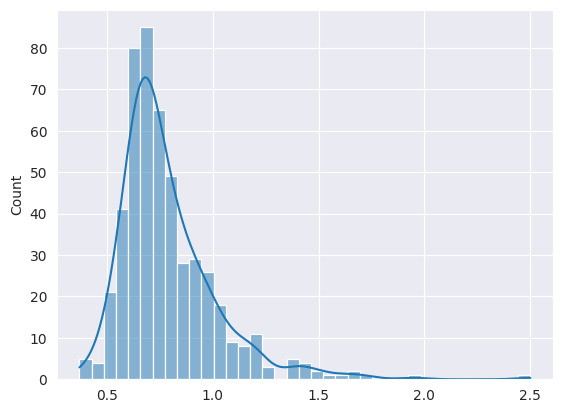

In [20]:
sns.histplot(samples["sim_data"]["rts"][0], kde=True, legend=False)